# Irrigation forecasting: why persistence ships

**Decision.** For the available Iron Horse Vineyard sensor history, the safest 6 to 48 hour soil-moisture forecast is the last observed value. This notebook reproduces a frozen seven-family benchmark end to end; nine further families were evaluated after it under the same protocol and are summarized in section 3b. Sixteen in total, and none of them changed what gets served.

This notebook tells that result from the pinned DVC sensor snapshot through forecast skill and irrigation-alert behavior. It is deliberately offline and calls VINE package APIs rather than rebuilding the pipeline or models here.

## Reproduction contract

1. From the repository root, materialize the pinned inputs once with `uv run dvc pull data/raw/sensors.dvc data/raw/weather.dvc`.
2. Restart the kernel and run all cells. No cell contacts InfluxDB, Open-Meteo, MLflow, or any other network service.
3. The frozen benchmark manifest is `configs/d2_irrigation/notebook_benchmark.yaml`; its seed, devices, horizons, folds, threshold, and seven challenger configs are the source of truth.

The DVC files pin the data version while `vine.d2_irrigation.data`, `vine.d2_irrigation.benchmark`, and the D5 evaluation APIs provide the executable analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vine.common import seed_everything
from vine.d2_irrigation import baselines
from vine.d2_irrigation.benchmark import load_benchmark_spec, run_benchmark
from vine.d2_irrigation.data import load_soil_probe_frames
from vine.d5_evaluation.metrics import binary_classification_metrics
from vine.d5_evaluation.walkforward import expanding_splits, purged_train_slice

ROOT = Path.cwd()
CONFIG = ROOT / "configs/d2_irrigation/notebook_benchmark.yaml"
COLORS = ["#2a78d6", "#eb6834", "#149e60", "#8e63ce", "#b65775", "#285bac", "#a46a21"]

spec = load_benchmark_spec(CONFIG)
seed_everything(spec.seed)
frames = load_soil_probe_frames()
required_devices = {spec.device, *spec.alert_devices}
missing = required_devices.difference(frames)
assert not missing, f"DVC snapshot is missing required probes: {sorted(missing)}"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. What data do we actually have?

The snapshot contains hourly feature frames derived from raw probe readings. Missingness is reported, not silently imputed. The benchmark probe is used for the seven-family forecast comparison; three additional probes are reserved here to check whether threshold-alert behavior generalizes beyond one series.

In [2]:
overview_rows = []
for device, frame in frames.items():
    moisture = frame["soil_water"]
    overview_rows.append(
        {
            "device": device,
            "start_utc": frame.index.min(),
            "end_utc": frame.index.max(),
            "hourly_rows": len(frame),
            "observed_moisture": int(moisture.notna().sum()),
            "missing_pct": 100 * moisture.isna().mean(),
            "mean": moisture.mean(),
            "min": moisture.min(),
            "max": moisture.max(),
            "below_threshold_pct": 100 * moisture.lt(spec.irrigate_below).mean(),
        }
    )

overview = pd.DataFrame(overview_rows).set_index("device")
overview.style.format(
    {
        "missing_pct": "{:.1f}%",
        "mean": "{:.2f}",
        "min": "{:.2f}",
        "max": "{:.2f}",
        "below_threshold_pct": "{:.1f}%",
    }
)

,start_utc,end_utc,hourly_rows,observed_moisture,missing_pct,mean,min,max,below_threshold_pct
device,,,,,,,,,
SE01-LS-1,2026-01-22 00:00:00+00:00,2026-07-08 17:00:00+00:00,4026,3401,15.5%,27.58,17.99,44.74,30.9%
SE01-LS-2,2026-01-22 00:00:00+00:00,2026-07-08 17:00:00+00:00,4026,3401,15.5%,21.32,15.44,44.84,74.9%
SE01-LS-3,2026-01-22 00:00:00+00:00,2026-07-08 17:00:00+00:00,4026,3401,15.5%,17.76,10.30,28.48,83.4%
SE01-LS-4,2026-01-22 00:00:00+00:00,2026-07-08 17:00:00+00:00,4026,3401,15.5%,23.28,17.25,41.44,68.6%
SE0X-LS-1,2026-01-22 00:00:00+00:00,2026-07-08 17:00:00+00:00,4026,3402,15.5%,18.92,11.81,60.46,81.7%


## 2. The central signal: soil moisture is highly persistent

A strong autocorrelation is not merely descriptive: it explains why the correct floor is a persistence forecast, not a global mean. The left panel measures correlation with earlier observations. The right panel makes the 24-hour forecast concrete: at each target hour, persistence predicts the value observed one day earlier.

The overlay is restricted to a recent window for legibility. Gaps remain gaps; lines are not filled across missing readings.

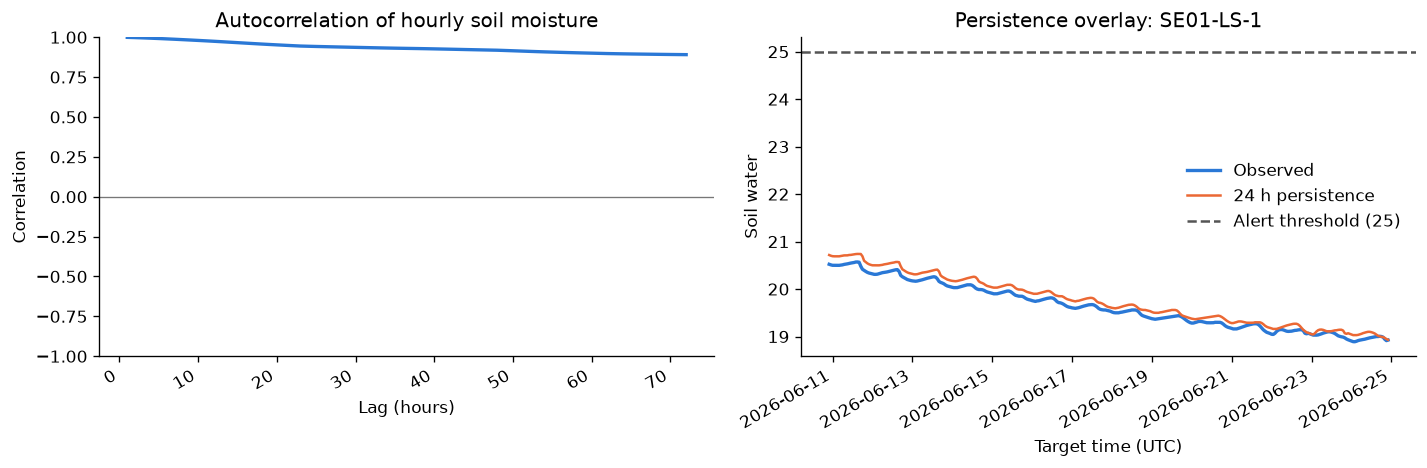

In [3]:
target = frames[spec.device]["soil_water"]
lags = np.arange(1, 73)
autocorrelation = pd.Series(
    [target.autocorr(lag=int(lag)) for lag in lags], index=lags, name="autocorrelation"
)

h_overlay = 24
persistence_24h = baselines.naive_persistence(target, h_overlay)
overlay = pd.concat(
    [target.rename("observed"), persistence_24h.rename("24 h persistence")], axis=1
).dropna()
overlay = overlay.loc[overlay.index.max() - pd.Timedelta(days=14) :]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(autocorrelation.index, autocorrelation, color=COLORS[0], linewidth=2)
axes[0].axhline(0, color="#777777", linewidth=0.8)
axes[0].set(
    title="Autocorrelation of hourly soil moisture", xlabel="Lag (hours)", ylabel="Correlation"
)
axes[0].set_ylim(-1, 1)

axes[1].plot(overlay.index, overlay["observed"], label="Observed", color=COLORS[0], linewidth=2)
axes[1].plot(
    overlay.index,
    overlay["24 h persistence"],
    label="24 h persistence",
    color=COLORS[1],
    linewidth=1.5,
)
axes[1].axhline(
    spec.irrigate_below,
    label=f"Alert threshold ({spec.irrigate_below:g})",
    color="#555555",
    linestyle="--",
)
axes[1].set(
    title=f"Persistence overlay: {spec.device}", xlabel="Target time (UTC)", ylabel="Soil water"
)
axes[1].legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 3. Frozen seven-family benchmark

The manifest declares seven challenger families: a recent-drydown rule, ridge, ridge with forecast-weather features, ridge on moisture change, ARIMA, random forest, and gradient-boosted trees. `run_benchmark` resolves each declared experiment config and delegates fitting and walk-forward scoring to the package.

**Reading skill:** `0` ties persistence; positive values improve on it; negative values are worse. Each challenger is scored against `matched_persistence_mae` on that challenger's exact non-missing rows, so models with different valid-row policies are not compared against an unrelated baseline denominator. Aggregate skill alone is not a ship gate. `skill_fold_min` exposes a model that wins on average by relying on one unusually easy interval but fails badly elsewhere.

In [4]:
benchmark = run_benchmark(frames[spec.device], spec)

columns = [
    "family",
    "model",
    "horizon_h",
    "n",
    "mae",
    "matched_persistence_mae",
    "rmse",
    "skill_vs_persistence",
    "skill_fold_median",
    "skill_fold_min",
    "precision",
    "recall",
]
skill_table = benchmark.loc[:, columns].copy()
skill_table.style.format(
    {
        "mae": "{:.3f}",
        "matched_persistence_mae": "{:.3f}",
        "rmse": "{:.3f}",
        "skill_vs_persistence": "{:+.1%}",
        "skill_fold_median": "{:+.1%}",
        "skill_fold_min": "{:+.1%}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    }
).background_gradient(subset=["skill_vs_persistence"], cmap="RdYlBu", vmin=-1, vmax=1)

2026-08-05T22:51:09.061666Z [info     ] evaluated horizon              horizon_h=6 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp'] n=1367


2026-08-05T22:51:09.075622Z [info     ] evaluated horizon              horizon_h=12 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp'] n=1361


2026-08-05T22:51:09.089483Z [info     ] evaluated horizon              horizon_h=24 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp'] n=1354


2026-08-05T22:51:09.103274Z [info     ] evaluated horizon              horizon_h=48 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp'] n=1335


2026-08-05T22:51:09.847394Z [info     ] evaluated horizon              horizon_h=6 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp', 'ridge'] n=1361


...

2026-08-05T22:51:49.905735Z [info     ] evaluated horizon              horizon_h=6 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp', 'gbt_delta'] n=1367


2026-08-05T22:52:10.797140Z [info     ] evaluated horizon              horizon_h=12 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp', 'gbt_delta'] n=1361


2026-08-05T22:52:34.076620Z [info     ] evaluated horizon              horizon_h=24 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp', 'gbt_delta'] n=1354


2026-08-05T22:52:59.145095Z [info     ] evaluated horizon              horizon_h=48 models=['persistence', 'drydown', 'seasonal_naive', 'diurnal_drift', 'climatology', 'diurnal_drift_temp', 'gbt_delta'] n=1335


,family,model,horizon_h,n,mae,matched_persistence_mae,rmse,skill_vs_persistence,skill_fold_median,skill_fold_min,precision,recall
0,arima,arima,6,1367,0.102,0.105,0.283,+3.0%,+2.6%,-0.1%,1.000,1.000
1,baseline,persistence,6,1367,0.105,0.105,0.287,+0.0%,+0.0%,+0.0%,1.000,1.000
2,gbt,gbt_delta,6,1367,0.109,0.105,0.252,-4.2%,-4.8%,-32.2%,1.000,1.000
3,forest,forest_delta,6,1361,0.115,0.105,0.282,-9.1%,-10.7%,-97.6%,1.000,1.000
4,rule,drydown,6,1367,0.117,0.105,0.326,-12.0%,-9.7%,-16.6%,1.000,1.000
5,ridge_delta,ridge_delta,6,1361,0.155,0.105,0.323,-47.7%,-53.7%,-137.0%,1.000,1.000
6,ridge_forecast,ridge,6,1361,0.160,0.105,0.328,-51.9%,-58.3%,-139.1%,1.000,1.000
7,baseline,seasonal_naive,6,1367,0.283,0.105,0.588,-170.1%,-104.5%,-203.4%,1.000,1.000
8,ridge,ridge,6,1361,0.331,0.105,0.483,-215.3%,-146.2%,-531.1%,1.000,1.000
9,baseline,climatology,6,1367,5.424,0.105,6.350,-5081.3%,-12953.1%,-15955.8%,0.000,0.000


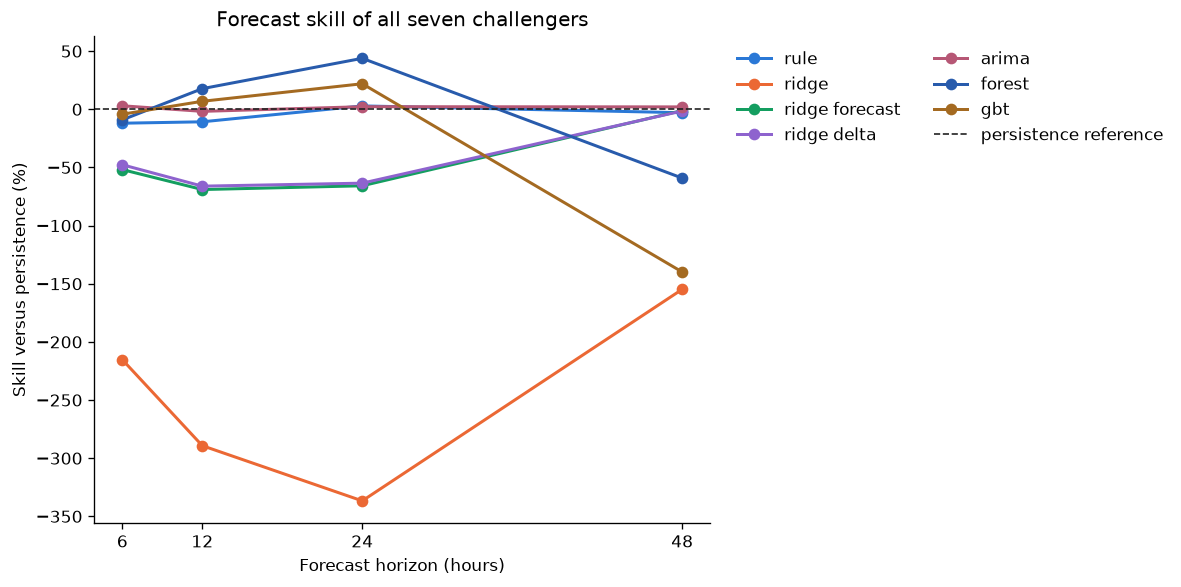

In [5]:
challengers = benchmark[benchmark["family"].ne("baseline")]
pivot = challengers.pivot(index="horizon_h", columns="family", values="skill_vs_persistence")
family_order = [challenger.family for challenger in spec.challengers]
pivot = pivot.reindex(columns=family_order)

fig, ax = plt.subplots(figsize=(10, 5))
for color, family in zip(COLORS, family_order, strict=True):
    ax.plot(
        pivot.index,
        100 * pivot[family],
        marker="o",
        linewidth=1.8,
        color=color,
        label=family.replace("_", " "),
    )
ax.axhline(0, color="#222222", linestyle="--", linewidth=1, label="persistence reference")
ax.set(
    title="Forecast skill of all seven challengers",
    xlabel="Forecast horizon (hours)",
    ylabel="Skill versus persistence (%)",
    xticks=spec.horizons_h,
)
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

The chart is intentionally anchored at the persistence reference rather than at zero MAE. A challenger can look numerically sophisticated and still add no dependable forecasting value. The table should be read from aggregate skill to median-fold skill and finally worst-fold skill; negative worst folds are the operational warning that prevented promotion.

## 3b. The nine families evaluated after this manifest

The manifest above is frozen so this notebook stays reproducible. Work continued past it, under the same walk-forward protocol and the same `h - 1` label purge, on all five probes rather than one. Full numbers live in the [model card](../docs/models/irrigation/persistence.md) and the dated reports under `docs/reports/`.

| # | Family | Outcome |
|---|--------|---------|
| 8 | Pooled cross-sensor ridge and GBT | Rejected |
| 9 | Water balance on realized weather | Rejected |
| 10 | Prophet with soil-temperature regressor | Rejected, loses at every horizon |
| 11 | LSTM encoder-decoder | Rejected, loses at every horizon |
| 12 | Diurnal drift in delta space | Rejected, fails the worst-fold gate |
| 13 | Cross-sensor error correction | Rejected, negative in 19 of 20 cells |
| 14 | Gaussian probabilistic (CRPS) | Wins on aggregate CRPS everywhere, fails worst fold in 3 of 20 cells |
| 15 | Rain-gated water balance | Rejected, 24 h fired subset negative on all probes |
| 16 | Filtered historical simulation | Passes the worst-fold gate in all 20 cells |

Rung 16 is the only family to clear the ADR-0003 gate. It is held as research rather than promoted, because it improves the uncertainty band around the forecast and leaves the center of the forecast, which is the number a grower acts on, identical to persistence. If a probabilistic product is ever wanted for the dashboard, that is the recipe to start from.

## 4. A small leak with a large consequence

For an `h`-hour target-time-aligned forecast, the first test target at time *t* is issued at *t − h*. An ordinary expanding split trains through the row immediately before *t*, so its newest `h − 1` target labels were not yet observable at the decision time. They cross the fold boundary even though every training timestamp is earlier than every test timestamp.

The corrected evaluator calls `purged_train_slice(train, purge=h - 1)`. The executable audit below marks exactly which labels the unpurged split would leak and confirms that the corrected slice retains only labels available when the first forecast is issued.

In [6]:
h = 6
index = pd.date_range("2026-01-01", periods=24, freq="h", tz="UTC")
train, test = expanding_splits(len(index), n_folds=2)[0]
corrected = purged_train_slice(train, purge=h - 1)
first_target_time = index[test.start]
decision_time = first_target_time - pd.Timedelta(hours=h)

positions = np.arange(max(0, train.stop - h - 2), train.stop)
audit = pd.DataFrame(
    {
        "target_time": index[positions],
        "known_at_first_decision": index[positions] <= decision_time,
        "included_unpurged": positions < train.stop,
        "included_after_h_minus_1_purge": positions < corrected.stop,
    },
    index=pd.Index(positions, name="row"),
)

leaked_labels = int((audit["included_unpurged"] & ~audit["known_at_first_decision"]).sum())
remaining_unavailable = int(
    (audit["included_after_h_minus_1_purge"] & ~audit["known_at_first_decision"]).sum()
)
assert leaked_labels == h - 1
assert remaining_unavailable == 0

print(
    f"First test target: {first_target_time}; decision time: {decision_time}; "
    f"unpurged unavailable labels: {leaked_labels}; after purge: {remaining_unavailable}"
)
audit

First test target: 2026-01-01 12:00:00+00:00; decision time: 2026-01-01 06:00:00+00:00; unpurged unavailable labels: 5; after purge: 0


,target_time,known_at_first_decision,included_unpurged,included_after_h_minus_1_purge
row,,,,
4,2026-01-01 04:00:00+00:00,True,True,True
5,2026-01-01 05:00:00+00:00,True,True,True
6,2026-01-01 06:00:00+00:00,True,True,True
7,2026-01-01 07:00:00+00:00,False,True,False
8,2026-01-01 08:00:00+00:00,False,True,False
9,2026-01-01 09:00:00+00:00,False,True,False
10,2026-01-01 10:00:00+00:00,False,True,False
11,2026-01-01 11:00:00+00:00,False,True,False


This is why a random split is not the only danger in forecasting. Even an expanding-window split needs horizon-aware label availability. The benchmark uses the corrected `h − 1` purge for every configured model and fold.

## 5. Does persistence still support the irrigation decision?

Forecast MAE is only an intermediate quantity. The operator-facing decision is whether predicted soil moisture falls below the configured threshold. We compare three transparent forecast rules at 24 hours on the held-out half of the three alert probes:

- **persistence:** last observed value;
- **seasonal naive:** value from the latest complete daily cycle;
- **drydown:** persistence plus a recent-slope extrapolation.

All rules are evaluated on one shared set of non-missing target/prediction rows. The confusion matrices use rows for actual decisions and columns for predicted decisions.

In [7]:
alert_horizon = 24
forecast_rules = {
    "persistence": lambda y: baselines.naive_persistence(y, alert_horizon),
    "seasonal naive": lambda y: baselines.seasonal_naive(y, alert_horizon),
    "drydown": lambda y: baselines.drydown_trend(y, alert_horizon),
}

metric_rows = []
pooled = {name: {"truth": [], "pred": []} for name in forecast_rules}
for device in spec.alert_devices:
    y = frames[device]["soil_water"]
    predictions = {name: rule(y) for name, rule in forecast_rules.items()}
    holdout_start = expanding_splits(len(y), spec.n_folds)[0][1].start
    valid = y.notna()
    for prediction in predictions.values():
        valid &= prediction.notna()
    valid.iloc[:holdout_start] = False

    truth = y[valid].lt(spec.irrigate_below).to_numpy()
    for name, prediction in predictions.items():
        alert = prediction[valid].lt(spec.irrigate_below).to_numpy()
        metrics = binary_classification_metrics(truth, alert)
        precision, recall = metrics["precision"], metrics["recall"]
        tn, fp = metrics["true_negative"], metrics["false_positive"]
        fn, tp = metrics["false_negative"], metrics["true_positive"]
        metric_rows.append(
            {
                "device": device,
                "forecast_rule": name,
                "n": len(truth),
                "precision": precision,
                "recall": recall,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
            }
        )
        pooled[name]["truth"].append(truth)
        pooled[name]["pred"].append(alert)

alert_metrics = pd.DataFrame(metric_rows)
alert_metrics.style.format({"precision": "{:.3f}", "recall": "{:.3f}"})

,device,forecast_rule,n,precision,recall,tn,fp,fn,tp
0,SE01-LS-2,persistence,1354,0.982,0.982,22,24,24,1284
1,SE01-LS-2,seasonal naive,1354,0.982,0.982,22,24,24,1284
2,SE01-LS-2,drydown,1354,0.978,0.984,17,29,21,1287
3,SE01-LS-3,persistence,1354,0.996,0.996,0,5,5,1344
4,SE01-LS-3,seasonal naive,1354,0.996,0.996,0,5,5,1344
5,SE01-LS-3,drydown,1354,0.996,0.982,0,5,24,1325
6,SE01-LS-4,persistence,1354,0.978,0.957,218,24,48,1064
7,SE01-LS-4,seasonal naive,1354,0.978,0.957,218,24,48,1064
8,SE01-LS-4,drydown,1354,0.946,0.999,178,64,1,1111


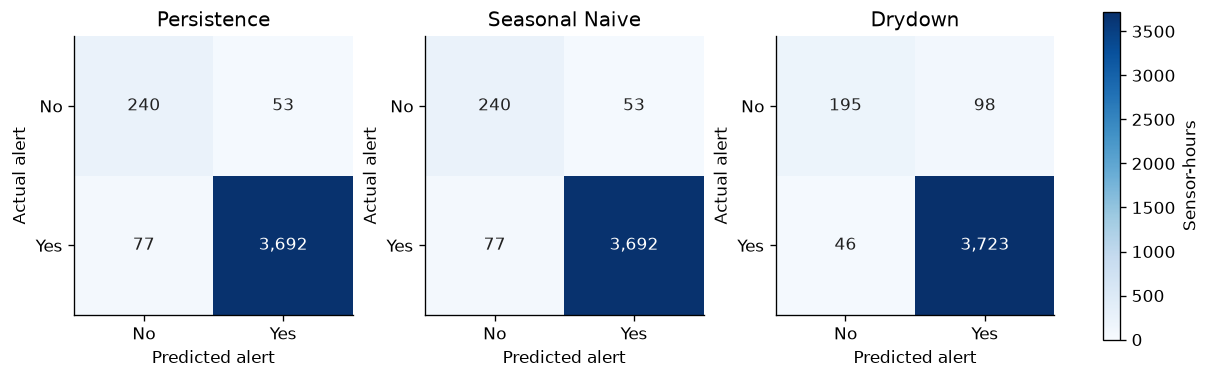

In [8]:
confusions = {}
for name, values in pooled.items():
    truth = np.concatenate(values["truth"])
    pred = np.concatenate(values["pred"])
    confusions[name] = np.array(
        [
            [(~truth & ~pred).sum(), (~truth & pred).sum()],
            [(truth & ~pred).sum(), (truth & pred).sum()],
        ],
        dtype=int,
    )

fig, axes = plt.subplots(1, len(confusions), figsize=(10, 3.5), constrained_layout=True)
max_count = max(matrix.max() for matrix in confusions.values())
for ax, (name, matrix) in zip(axes, confusions.items(), strict=True):
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max_count)
    for row in range(2):
        for col in range(2):
            color = "white" if matrix[row, col] > max_count / 2 else "#222222"
            ax.text(col, row, f"{matrix[row, col]:,}", ha="center", va="center", color=color)
    ax.set(
        title=name.title(),
        xlabel="Predicted alert",
        ylabel="Actual alert",
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
    )
fig.colorbar(image, ax=axes, label="Sensor-hours", shrink=0.8)
plt.show()

## Conclusion

Persistence is not a placeholder awaiting a more complicated model; it is the evidence-backed D2 champion for this snapshot. Strong short-range autocorrelation makes it difficult to beat, the corrected horizon-aware evaluation removes optimistic fold-boundary information, and the challenger gains are not stable enough to ship. At the same time, persistence preserves useful threshold alerts on probes that cross the irrigation boundary.

The operational stance is therefore conservative: serve persistence plus the typed threshold decision, retain freshness and quality checks, and revisit model promotion only when a challenger shows positive aggregate **and** robust per-fold, multi-probe skill using weather information available at forecast time.